In [ ]:
#Linear Regression Model

RMSE error = 0.9117569987869609
OLS coefficients = [1.93761684 1.31425174]


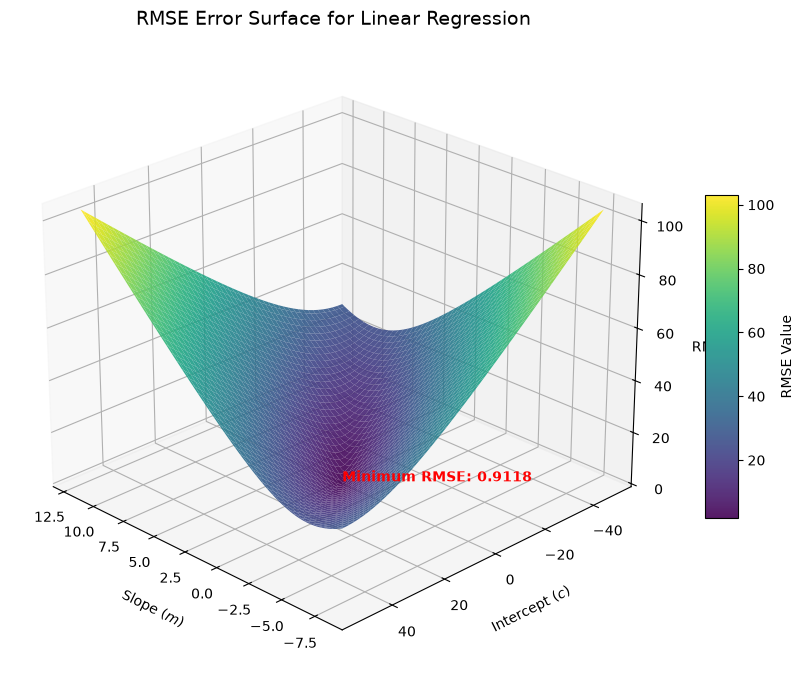

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

class Linear_Regression:
    def __init__(self, dataset):
        pass
        self.dataset = np.asarray(dataset, dtype=float)
        self.coefficients = np.zeros(2)

    def calculate_error_RMSE(self, coefficients = None):
        if coefficients is None:
            coefficients = self.coefficients
        predicted_output = self.dataset[0]*coefficients[0] + coefficients[1]
        actual_output = self.dataset[1]
        error = np.sqrt(np.mean(np.square(predicted_output - actual_output)))
        return error

    def calculate_R2(self, coefficients = None):
        if coefficients is None:
            coefficients = self.coefficients
        predicted_output = self.dataset[0]*coefficients[0] + coefficients[1]
        actual_output = self.dataset[1]
        error = np.mean(np.square(predicted_output - actual_output))
        mean_error = np.mean(np.square(actual_output - np.mean(actual_output)))
        R2 = 1 - error/mean_error
        return R2

    def OLS(self):
        x = self.dataset[0]
        y = self.dataset[1]
        x_mean = np.mean(x)
        y_mean = np.mean(y)
        slope = np.sum((x - x_mean)*(y - y_mean)) / np.sum((x - x_mean)**2)
        intercept = y_mean - slope*x_mean
        self.coefficients = np.array([slope, intercept])
        return np.array([slope, intercept])
    def predict(self, x=None):
        if x is None:
            x = self.dataset[0]
        return self.coefficients[0]*x + self.coefficients[1]

    def visualize(self):
        plt.scatter(self.dataset[0], self.dataset[1], label='Observed Value')
        plt.plot(self.dataset[0], self.predict(), label='Predicted Value', color='red')
        plt.xlabel('<--X-Axis-->')
        plt.ylabel('<--Y-Axis-->')
        plt.legend()
        plt.show()

    def visualize3D(self, zoom_m=1, zoom_c=1):

        m_range = np.linspace(self.coefficients[0] - 5*zoom_m, self.coefficients[0] + 5*zoom_m, 100)
        c_range = np.linspace(self.coefficients[1] - 5*zoom_c, self.coefficients[1] + 5*zoom_c, 100)
        M, C = np.meshgrid(m_range, c_range)
        RMSE = np.zeros(M.shape)
        for i in range(M.shape[0]):
            for j in range(M.shape[1]):
                coefficients = np.array([M[i, j], C[i, j]])
                RMSE[i, j] = self.calculate_error_RMSE(coefficients)


        #plot surface
        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(111, projection='3d')

        # plot with color map
        surface = ax.plot_surface(M, C, RMSE, cmap='viridis', edgecolor='none', alpha=0.9)

        # labels
        ax.set_xlabel('Slope ($m$)', labelpad=10)
        ax.set_ylabel('Intercept ($c$)', labelpad=10)
        ax.set_zlabel('RMSE', labelpad=10)
        ax.set_title('RMSE Error Surface for Linear Regression', fontsize=14)

        ax.text(self.coefficients[0], self.coefficients[1], self.calculate_error_RMSE(),
        s="Minimum RMSE: {:.4f}".format(self.calculate_error_RMSE()), 
        color='red', 
        fontweight='bold')
        # Add a color bar map to show error scale
        fig.colorbar(surface, ax=ax, shrink=0.5, aspect=10, label='RMSE Value')

        # Adjust the viewing angle for better perspective orientation
        ax.view_init(elev=25, azim=135)

        # Show the plot
        plt.tight_layout()
        plt.show()
if __name__ == "__main__":
    x = np.linspace(0, 10, 100)
    y = 2 * x + 1 + np.random.normal(0, 1, size=x.shape)

    Dataset = [x, y]

    Linear = Linear_Regression(Dataset)
    Linear.OLS()
    print("RMSE error = " + str(Linear.calculate_error_RMSE()))
    print("OLS coefficients = " + str(Linear.OLS()))
    Linear.visualize3D(zoom_m=2, zoom_c=10)



In [ ]:
#UNSW Linear Regression (using script)

Slope: 1237.8134984323494
Intercept: -15111.70325558421
RMSE: 44536.65903604502
R²: 0.9326725622970665


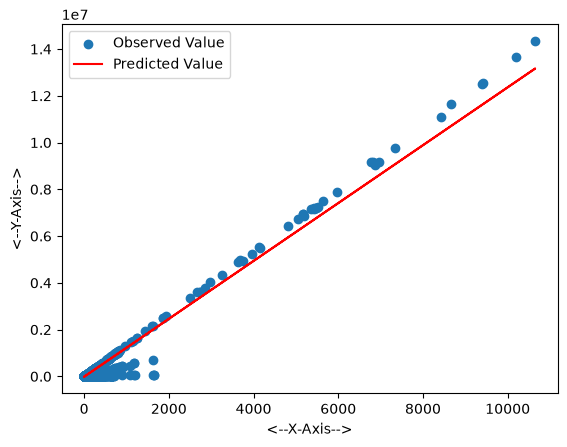

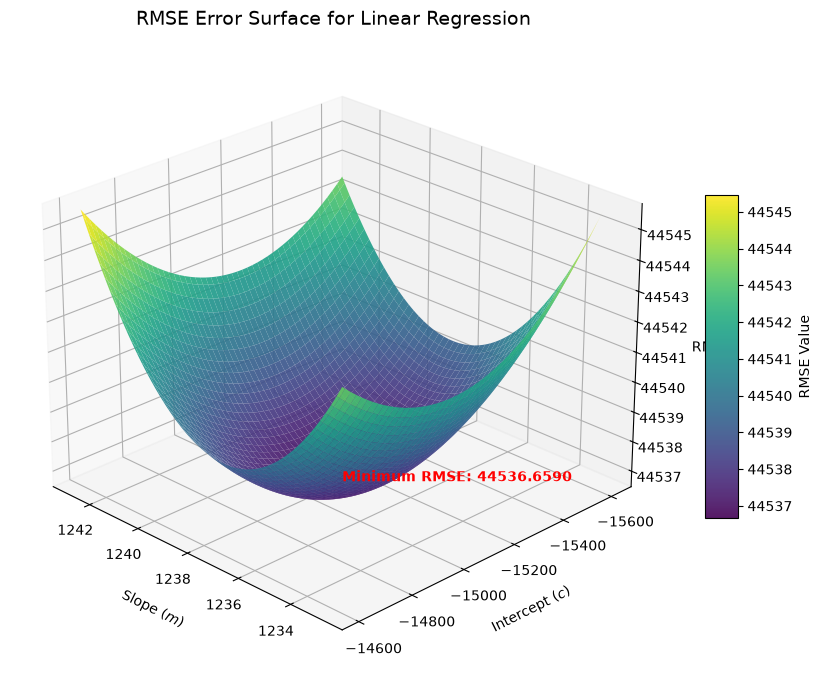

In [3]:
import pandas as pd
import numpy as np
from Linear_Reg import Linear_Regression

df = pd.read_csv("unsw-nb15/versions/1/UNSW_NB15_training-set.csv")

x = df["spkts"].values
y = df["sbytes"].values
dataset = [x, y]

model = Linear_Regression(dataset)
model.OLS()

print("Slope:", model.coefficients[0])
print("Intercept:", model.coefficients[1])
print("RMSE:", model.calculate_error_RMSE())
print("R²:", model.calculate_R2())

model.visualize()
model.visualize3D(zoom_c= 100)

In [ ]:
#Linear Regression using Scikit

In [4]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


def main():
    # Load dataset
    df = pd.read_csv("unsw-nb15/versions/1/UNSW_NB15_training-set.csv")

    # Target: predict total bytes sent
    target_col = "dur"  # Replace with the actual target column name if different

    # Keep only numeric features; exclude the target and ID columns
    feature_cols = df.select_dtypes(include=["number"]).columns.tolist()
    feature_cols = [c for c in feature_cols if c not in {"id", target_col}]

    X = df[feature_cols]
    y = df[target_col]

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Fill missing values and train linear regression
    imputer = SimpleImputer(strategy="median")
    X_train_imputed = imputer.fit_transform(X_train)
    X_test_imputed = imputer.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_imputed, y_train)

    predictions = model.predict(X_test_imputed)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    print("Model: Linear Regression")
    print("Target:", target_col)
    print("Features used:", len(feature_cols))
    print("RMSE:", rmse)
    print("R^2:", r2)

if __name__ == "__main__":
    main()


Model: Linear Regression
Target: dur
Features used: 39
RMSE: 4.268437324281551
R^2: 0.1535706733434723
